# Train Basketball Detector

---

This notebook is based on the [How to Train YOLOv8 Object Detection on a Custom Dataset](https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-object-detection-on-custom-dataset.ipynb) notebook from the [roboflow/notebooks](https://github.com/roboflow/notebooks) repository.

## Configure API keys

- Open your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install dependencies

In [3]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.1 MB/s eta 0:00:00


## Imports

In [4]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

## Pull dataset

In [5]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

/content/datasets


Dataset A (base classes):

In [ ]:
project = rf.workspace("roboflow-universe-projects").project("basketball-players-fy4c2")
version = project.version(25)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Basketball-Players-25 in yolo26:: 100%|██████████| 2404/2404 [00:00<00:00, 4302.14it/s]


Dataset B (with action classes):

In [6]:
project = rf.workspace("roboflow-jvuqo").project("basketball-player-detection-3-ycjdo")
version = project.version(18)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to basketball-player-detection-3-18 in yolo26:: 100%|██████████| 1313/1313 [00:00<00:00, 3596.95it/s]


**NOTE:** Update `data.yaml` structure to align with the latest requirements of the `ultralytics` package.

**NOTE:** Don't run for yolo26 dataset versions. Only for yolov8 dataset versions.


In [ ]:
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

## (Optional) Drop Unnecessary Classes
Dataset might have unnecessary classes that we don't want the model to learn.


Check what classes we have:

In [7]:
from pathlib import Path
from collections import Counter
import yaml

dataset_path = Path(dataset.location)

# load yaml
with open(dataset_path / "data.yaml", "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

# count annotations
class_counter = Counter()

label_dirs = [
    dataset_path / "train" / "labels",
    dataset_path / "valid" / "labels",
    dataset_path / "test" / "labels",
]

for label_dir in label_dirs:
    for label_file in label_dir.glob("*.txt"):

        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            if line.strip():
                cls_id = int(line.split()[0])
                class_counter[cls_id] += 1

print("\n=== DATASET CLASSES ===\n")

for cls_id, cls_name in enumerate(class_names):
    count = class_counter[cls_id]
    print(f"{cls_id}: {cls_name} -> {count} annotations")


=== DATASET CLASSES ===

0: ball -> 608 annotations
1: ball-in-basket -> 50 annotations
2: number -> 3944 annotations
3: player -> 6105 annotations
4: player-in-possession -> 121 annotations
5: player-jump-shot -> 105 annotations
6: player-layup-dunk -> 33 annotations
7: player-shot-block -> 87 annotations
8: referee -> 1788 annotations
9: rim -> 644 annotations


Remove classes:

In [8]:
from pathlib import Path
import yaml

dataset_path = Path(dataset.location)

# classes to keep
KEEP_CLASSES = [0, 1, 3, 4, 5, 6, 7, 8, 9]

# mapping old -> new ids
new_class_map = {
    old_id: new_id
    for new_id, old_id in enumerate(KEEP_CLASSES)
}

# label folders
label_dirs = [
    dataset_path / "train" / "labels",
    dataset_path / "valid" / "labels",
    dataset_path / "test" / "labels",
]

for label_dir in label_dirs:

    for label_file in label_dir.glob("*.txt"):

        filtered_lines = []

        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) == 0:
                continue

            old_cls = int(parts[0])

            # keep only desired classes
            if old_cls in KEEP_CLASSES:

                # remap class ids
                parts[0] = str(new_class_map[old_cls])

                filtered_lines.append(" ".join(parts))

        # overwrite label file
        with open(label_file, "w") as f:
            f.write("\n".join(filtered_lines))

# update data.yaml
yaml_path = dataset_path / "data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

old_names = data["names"]

new_names = [old_names[i] for i in KEEP_CLASSES]

data["names"] = new_names
data["nc"] = len(new_names)

with open(yaml_path, "w") as f:
    yaml.dump(data, f)

print("\nDataset successfully filtered.")
print("Remaining classes:")

for i, name in enumerate(new_names):
    print(f"{i}: {name}")


Dataset successfully filtered.
Remaining classes:
0: ball
1: ball-in-basket
2: player
3: player-in-possession
4: player-jump-shot
5: player-layup-dunk
6: player-shot-block
7: referee
8: rim


## Custom training

In [9]:
%cd {HOME}

!yolo task=detect mode=train model=yolo26x.pt data={dataset.location}/data.yaml batch=64 epochs=100 imgsz=640 plots=True

/content
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/basketball-player-detection-3-18/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=

In [10]:
!ls {HOME}/runs/detect/train/

args.yaml			 labels.jpg	     train_batch721.jpg
BoxF1_curve.png			 results.csv	     train_batch722.jpg
BoxP_curve.png			 results.png	     val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg    val_batch0_pred.jpg
BoxR_curve.png			 train_batch1.jpg    weights
confusion_matrix_normalized.png  train_batch2.jpg
confusion_matrix.png		 train_batch720.jpg


/content


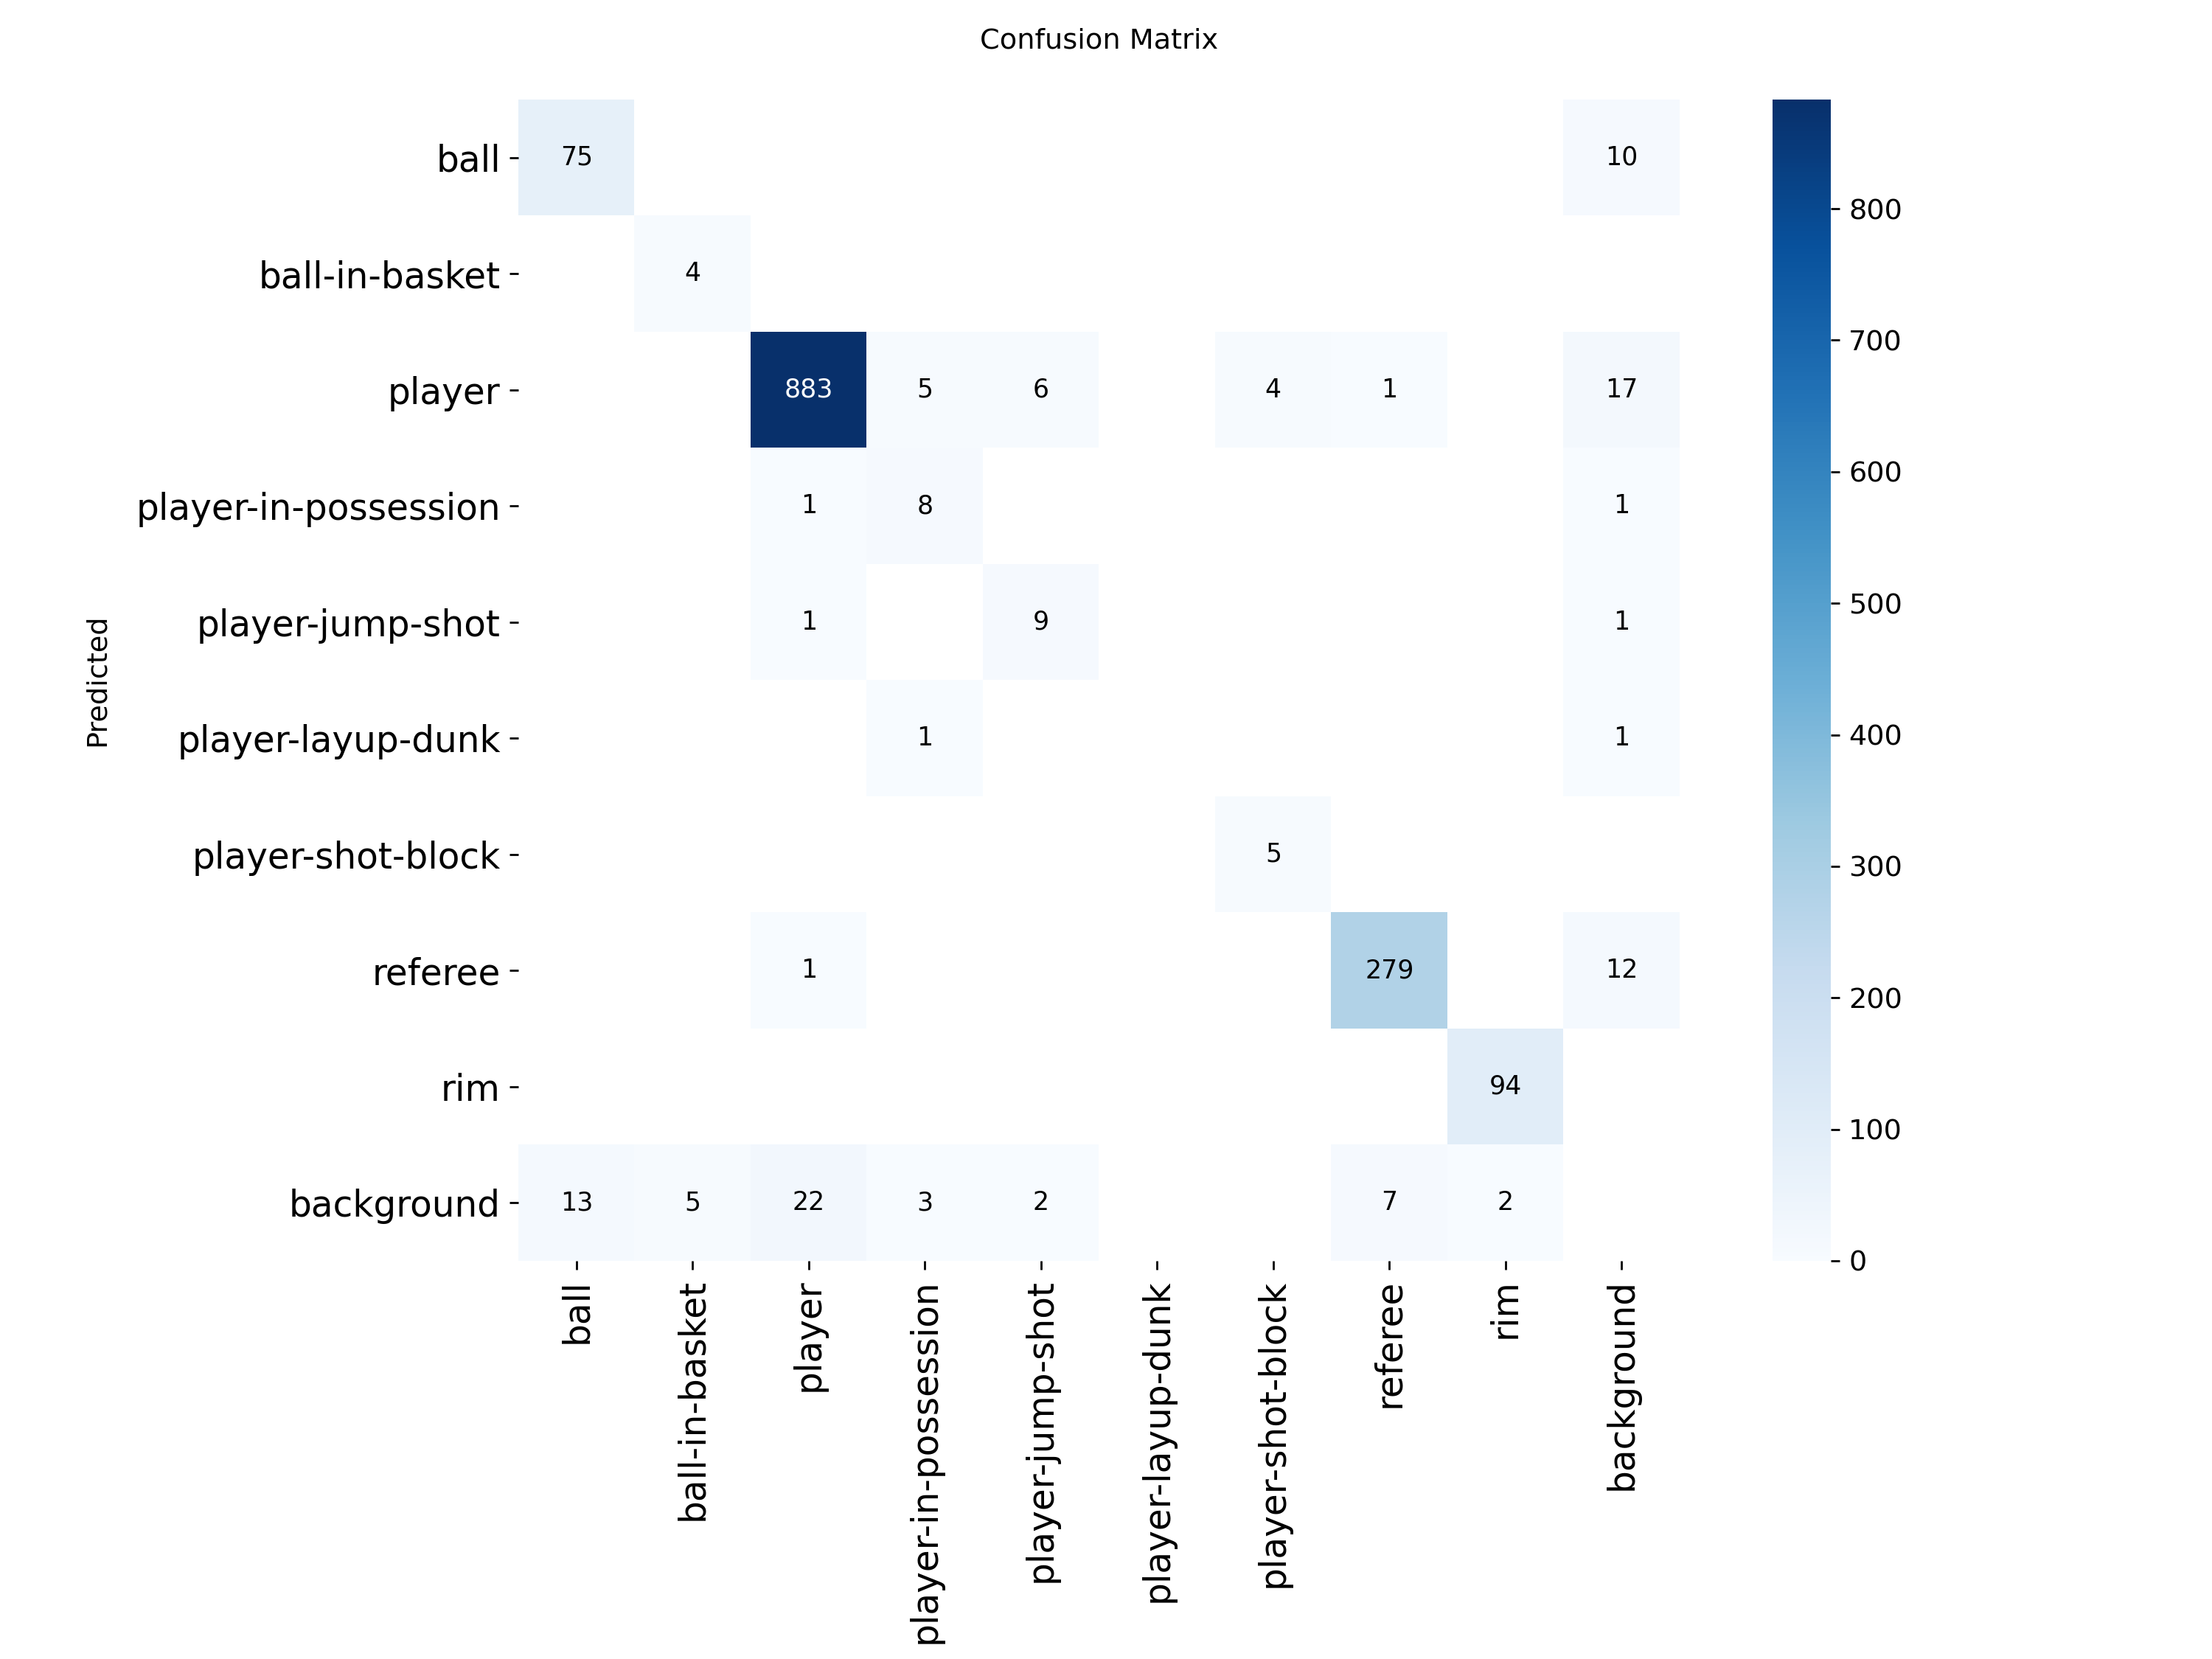

In [11]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


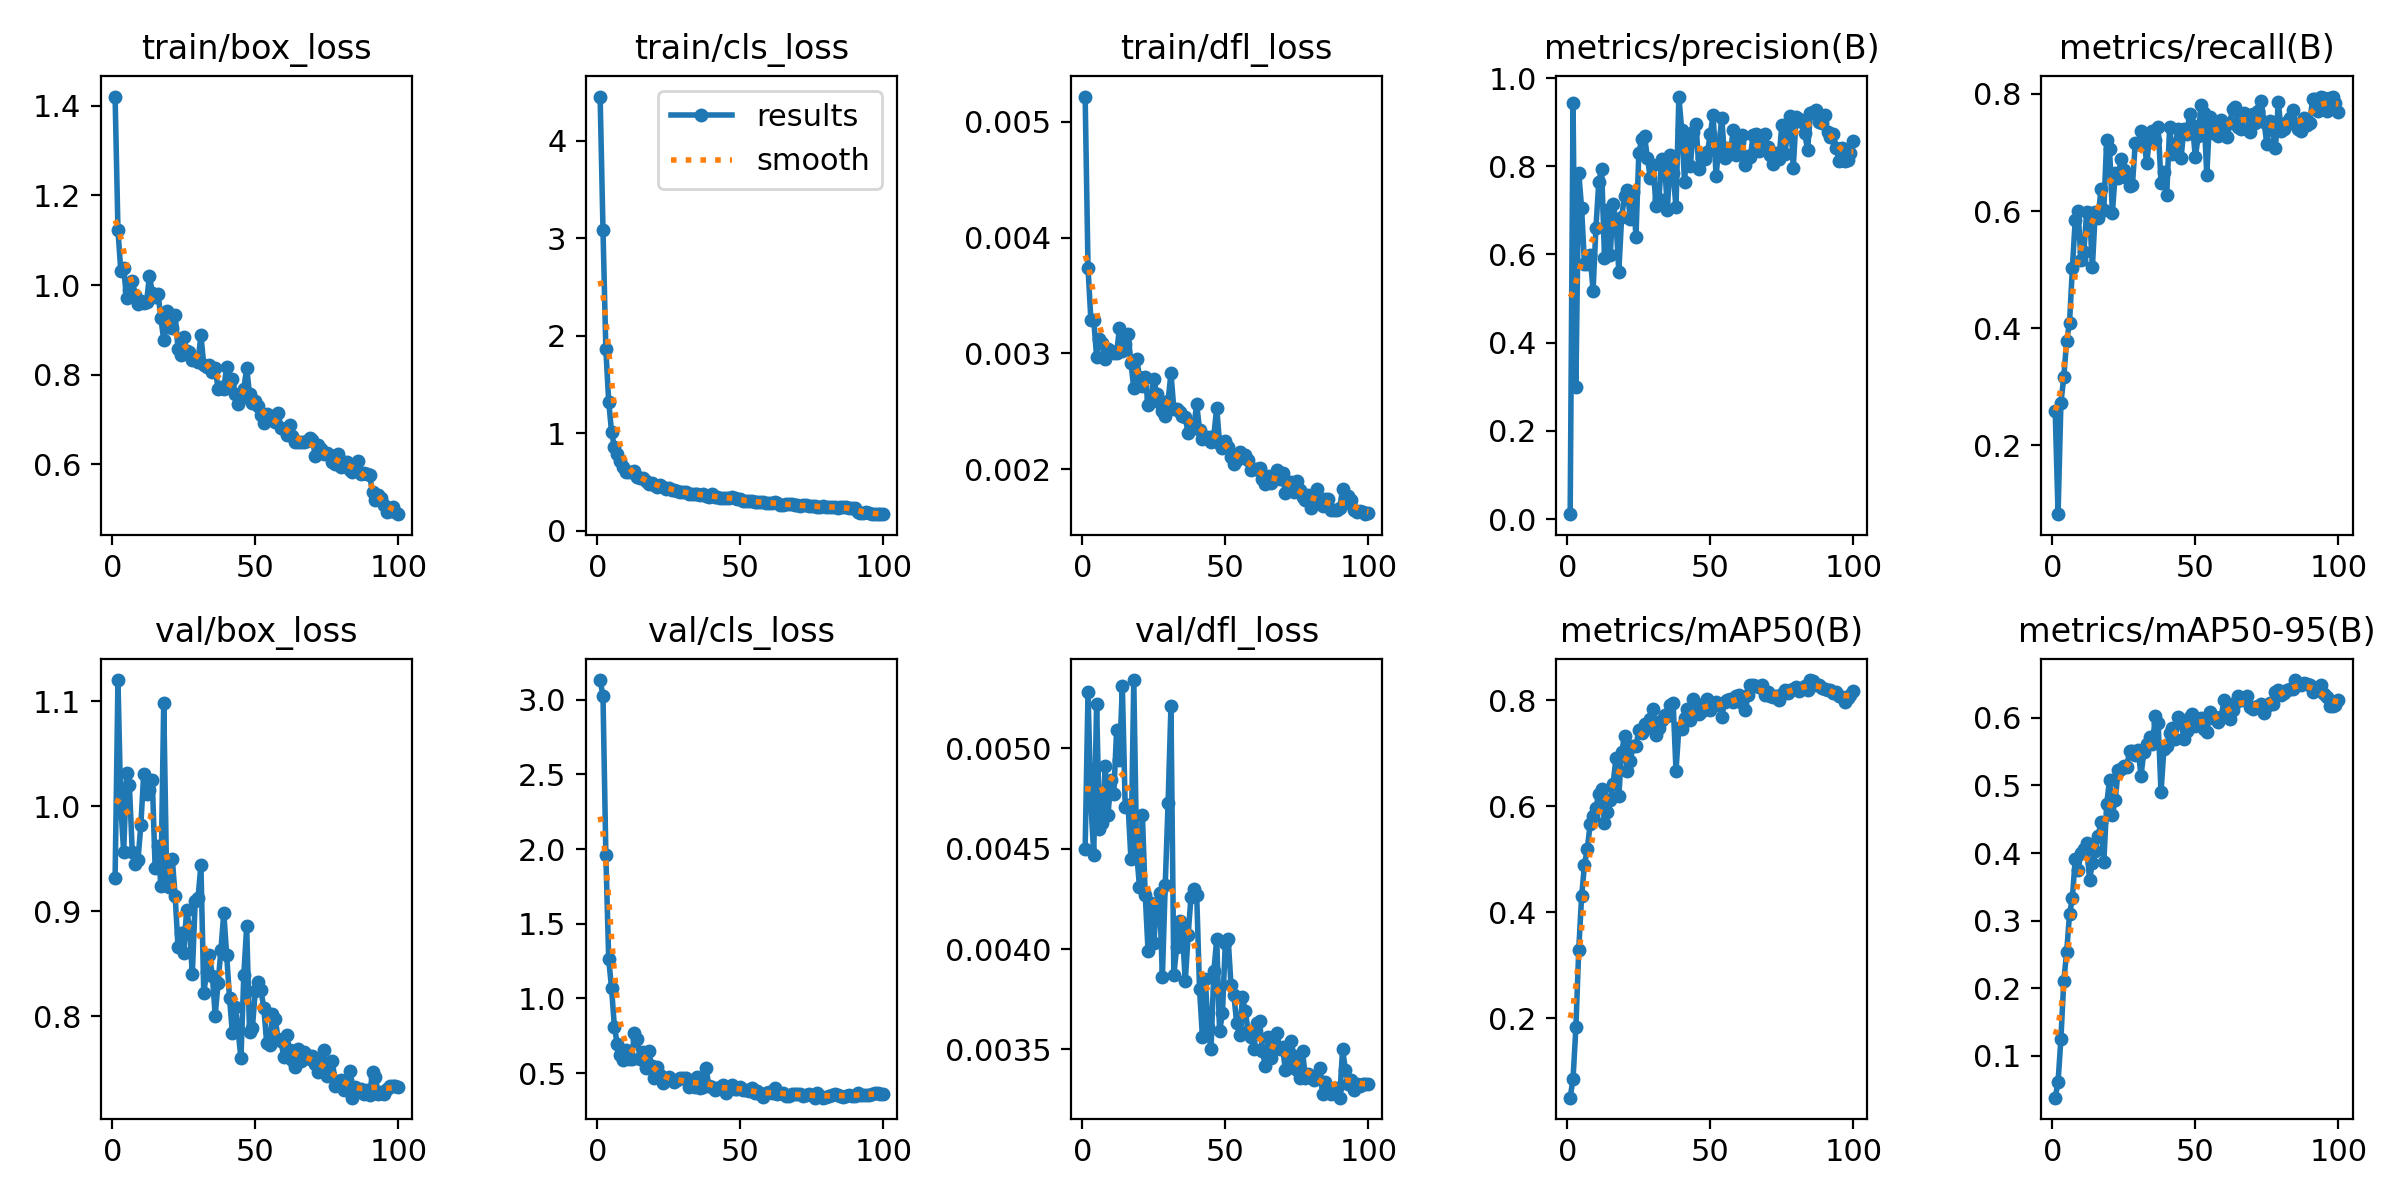

In [12]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


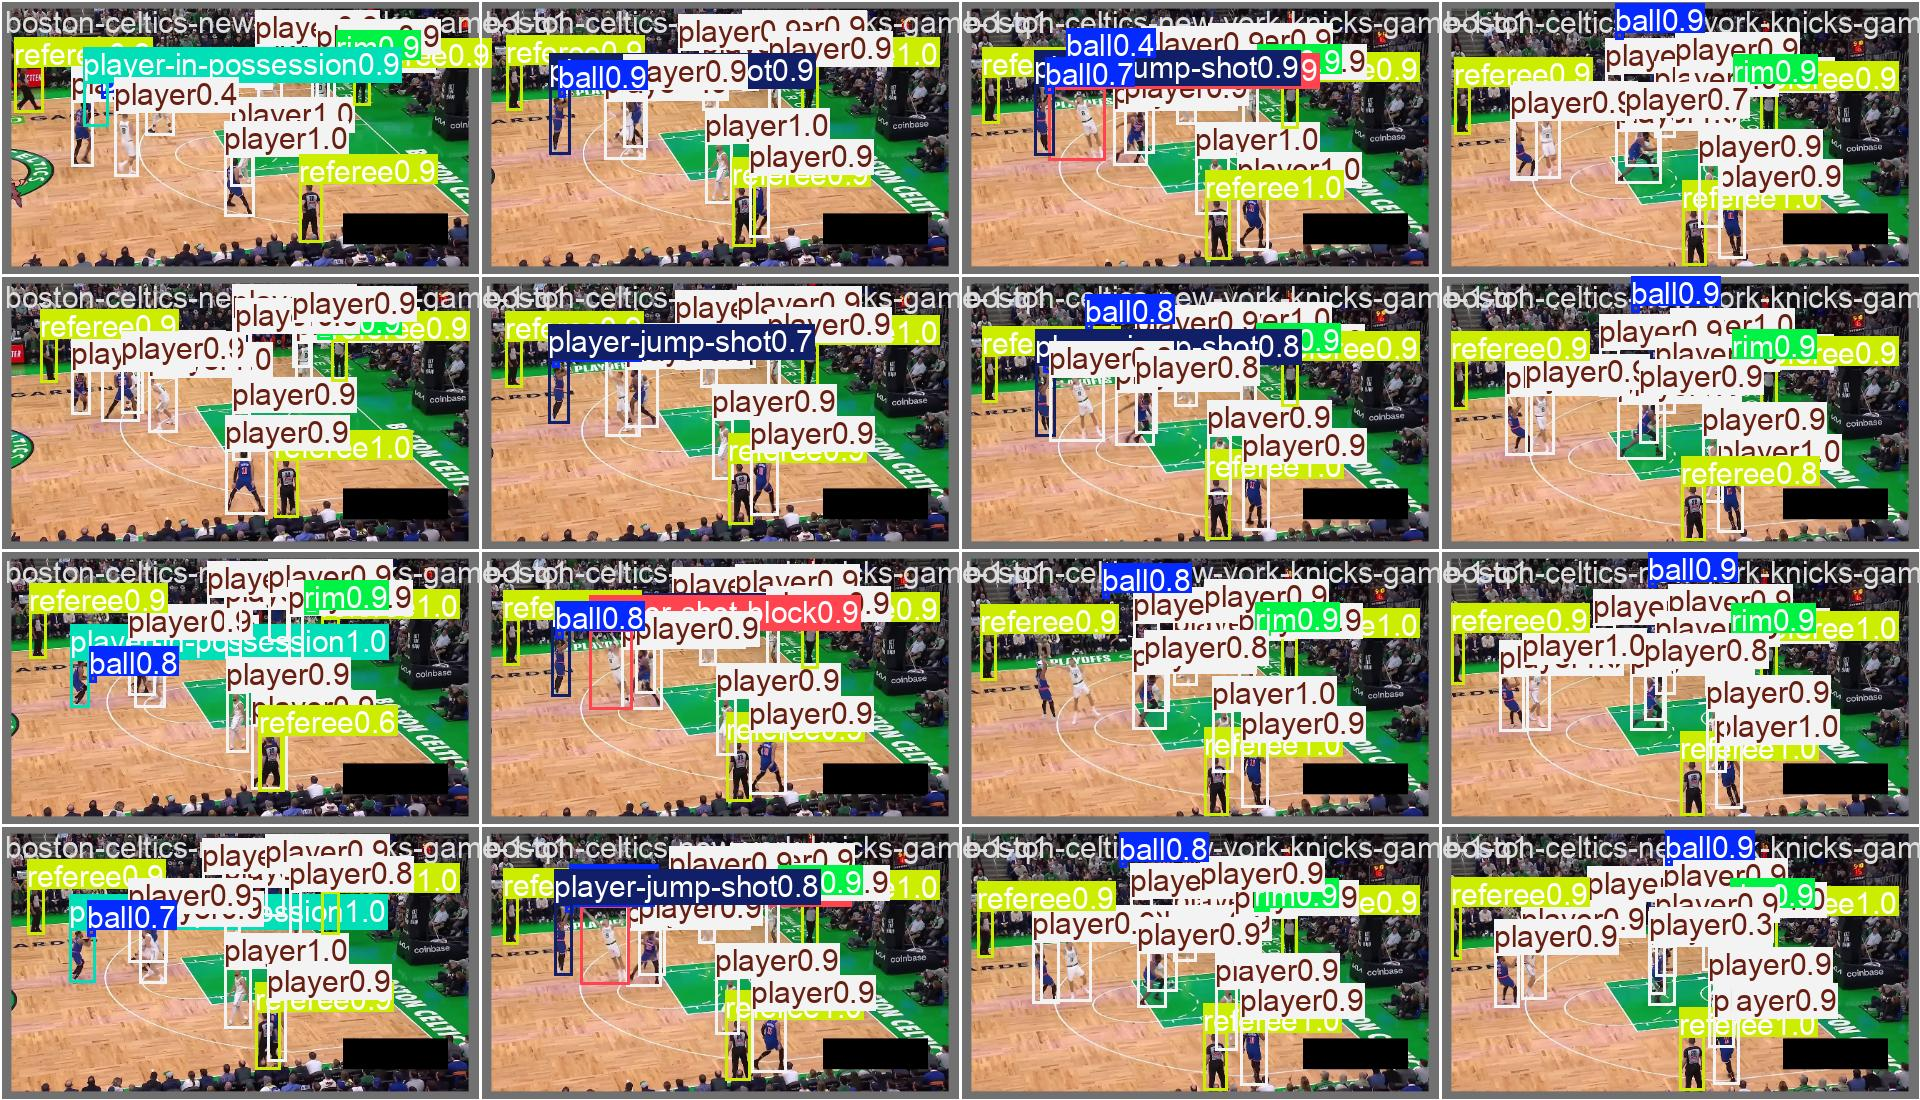

In [13]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate custom model

In [14]:
import pandas as pd
from ultralytics import YOLO

In [15]:
model = YOLO(f"{HOME}/runs/detect/train/weights/best.pt")

metrics = model.val(
    data=f"{dataset.location}/data.yaml",
    imgsz=1280
)

precision = float(metrics.box.mp)   # mean precision
recall = float(metrics.box.mr)      # mean recall

f1 = (2 * precision * recall) / (precision + recall + 1e-16)

results = {
    "precision": precision,
    "recall": recall,
    "F1": f1,
    "mAP50": float(metrics.box.map50),
    "mAP50-95": float(metrics.box.map)
}

df = pd.DataFrame([results])

output_path = f"{HOME}/runs/detect/val/val_metrics.csv"
df.to_csv(output_path, index=False)

print(df)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO26x summary (fused): 190 layers, 55,643,943 parameters, 0 gradients, 193.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2920.4±228.8 MB/s, size: 250.9 KB)
val: Scanning /content/datasets/basketball-player-detection-3-18/valid/labels.cache... 96 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 96/96 14.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7it/s 3.6s
                   all         96       1431       0.59       0.69      0.651      0.481
                  ball         88         88      0.696      0.886      0.875      0.564
        ball-in-basket          9          9      0.233      0.556      0.453      0.321
                player         96        908      0.866      0.981      0.985      0.821
  player-in-possession         17         17      0.397      0.647       0.43      0.328


## (Optional) Save run
Save all files from the model run for thesis.

In [16]:
FOLDER_NAME = "player-detector-B-yolo26x-run" # Input desired folder name.

In [17]:
from google.colab import files
import shutil

# create zip
shutil.make_archive(FOLDER_NAME, "zip", f'{HOME}/runs/detect')

# download
files.download(f'{FOLDER_NAME}.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>